# Reproducing the figures of the FSHD dataset analysis with **minkiPy**

This notebook is designed to **reproduce the figures presented in the paper** using the **minkiPy** framework. It provides a complete and reproducible workflow.

The notebook performs the following steps:

1. **Download the raw dataset** used in the study.
2. **Compute Minkowski profiles** using the **minkiPy** pipeline.
3. **Run the downstream analysis** and **generate the figures**

### Download and extract the raw dataset

The following cell downloads the **raw dataset used in the paper** from Zenodo and extracts it locally.  

The archive (~10 GB) is downloaded as `raw_data.zip` and extracted into the `raw_data/` directory.

In [15]:
from pathlib import Path
import requests
import zipfile

url = "https://zenodo.org/records/11100095/files/raw_data.zip?download=1"

out_dir = Path("examples/FSHD_dataset")
out_dir.mkdir(exist_ok=True)

zip_path = out_dir / "raw_data.zip"
extract_dir = out_dir / "raw_data"

# --- Download in streaming mode ---
with requests.get(url, stream=True) as r:
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    downloaded = 0
    chunk_size = 1024 * 1024  # 1 MB

    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total > 0:
                    pct = 100 * downloaded / total
                    print(
                        f"\rDownloaded {downloaded / 1e9:.2f} / {total / 1e9:.2f} GB ({pct:.1f}%)",
                        end=""
                    )

print("\nDownload finished.")

# --- Unzip ---
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print(f"Extracted to: {extract_dir.resolve()}")

# --- Remove zip file after successful extraction ---
zip_path.unlink()
print(f"Removed archive: {zip_path.resolve()}")

Downloaded 10.28 / 10.28 GB (100.0%)
Download finished.
Extracted to: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/FSHD_dataset/raw_data
Removed archive: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/FSHD_dataset/raw_data.zip


## Preprocessing of the MERFISH FSHD dataset and Minkowski profile estimation

In this step, we load the **raw MERFISH transcript data** provided with the FSHD dataset.  
Following the protocol described in the original publication, we apply the **spatial mask provided with the data** (the `centerRegionBoundaries` files) in order to retain only transcripts located inside the **selected central region**. This region is defined by an elliptical-like boundary and corresponds to the area used in the original analysis.

The preprocessing therefore consists of:
- removing control probes (`Blank` genes),
- selecting only transcripts located **inside the provided mask**, and

Once the transcripts are filtered, we compute **Minkowski profiles** using `minkiPy` for each gene in each sample.  
This procedure is applied to the **ten MERFISH samples** included in the dataset, and the resulting profiles (together with Monte Carlo realisations used for covariance estimation) are written to disk for subsequent analysis.

In [17]:
import minkiPy
import os
import numpy as np
import pandas as pd
import matplotlib.path as mpltPath


def user_preprocessing_MERFISH(name):
    transcripts_path = 'examples/FSHD_dataset/raw_data/transcript_data/'
    transcripts_files = [
        'batch1_region0_detected_transcripts.csv',  # FSHD1
        'batch1_region2_detected_transcripts.csv',  # Control
        'batch2_region0_detected_transcripts.csv',  # Control
        'batch2_region1_detected_transcripts.csv',  # FSHD1
        'batch3_region0_detected_transcripts.csv',  # FSHD1
        'batch3_region1_detected_transcripts.csv',  # Control
        'batch3_region2_detected_transcripts.csv',  # DEL5
        'batch4_region0_detected_transcripts.csv',  # FSHD1
        'batch4_region1_detected_transcripts.csv',  # DEL5
        'batch4_region2_detected_transcripts.csv'   # Control
    ]

    mask_path = 'examples/FSHD_dataset/raw_data/selected_center_region/'
    mask_files = [
        'batch1/region0/centerRegionBoundaries.csv',
        'batch1/region2/centerRegionBoundaries.csv',
        'batch2/region0/centerRegionBoundaries.csv',
        'batch2/region1/centerRegionBoundaries.csv',
        'batch3/region0/centerRegionBoundaries.csv',
        'batch3/region1/centerRegionBoundaries.csv',
        'batch3/region2/centerRegionBoundaries.csv',
        'batch4/region0/centerRegionBoundaries.csv',
        'batch4/region1/centerRegionBoundaries.csv',
        'batch4/region2/centerRegionBoundaries.csv'
    ]

    name_to_index = {
        'batch1_FSHD1': 0,
        'batch1_Control': 1,
        'batch2_Control': 2,
        'batch2_FSHD1': 3,
        'batch3_FSHD1': 4,
        'batch3_Control': 5,
        'batch3_DEL5': 6,
        'batch4_FSHD1': 7,
        'batch4_DEL5': 8,
        'batch4_Control': 9
    }

    if name not in name_to_index:
        raise ValueError(f"Unknown dataset name: {name}")

    i = name_to_index[name]

    # --- Read transcripts ---
    transcripts_file = os.path.join(transcripts_path, transcripts_files[i])
    dft = pd.read_csv(transcripts_file, dtype={9: str})

    # Keep only non-blank genes
    dft = dft[~dft["gene"].str.startswith("Blank", na=False)].copy()

    # Recenter transcript coordinates
    min_x = dft["global_x"].min()
    min_y = dft["global_y"].min()
    dft["adjusted_x"] = dft["global_x"] - min_x
    dft["adjusted_y"] = dft["global_y"] - min_y

    # --- Read mask ---
    mask_file = os.path.join(mask_path, mask_files[i])
    dfm = pd.read_csv(mask_file, header=None)

    x_mask = dfm[0].to_numpy()
    y_mask = dfm[1].to_numpy()
    mask_polygon = np.column_stack((x_mask, y_mask))
    path = mpltPath.Path(mask_polygon)

    # --- Keep only transcripts inside mask ---
    points = dft[["adjusted_x", "adjusted_y"]].to_numpy()
    inside = path.contains_points(points)
    filtered_dft = dft.loc[inside].copy()

    # Recenter again after filtering
    filtered_dft["global_x"] = filtered_dft["adjusted_x"] - filtered_dft["adjusted_x"].min()
    filtered_dft["global_y"] = filtered_dft["adjusted_y"] - filtered_dft["adjusted_y"].min()

    # Return only the columns expected downstream
    filtered_dft = filtered_dft[["gene", "global_x", "global_y"]].reset_index(drop=True)

    return filtered_dft

names = [
    'batch1_FSHD1',
    'batch1_Control',
    'batch2_Control',
    'batch2_FSHD1',
    'batch3_FSHD1',
    'batch3_Control',
    'batch3_DEL5',
    'batch4_FSHD1',
    'batch4_DEL5',
    'batch4_Control'
]

for name in names:
    df= user_preprocessing_MERFISH(name)
    
    outdir = "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis"
    os.makedirs(outdir, exist_ok=True)
    
    h5 = minkiPy.compute_Minkowski_profiles(
        df,
        name=name,
        output_path=outdir,
        resolution=20.0,
        nbr=30,
        overwrite=True,
        mpi_procs=60, # adapt this line to the number of threads you want to use
        use_hwthreads=True,
    )

[Rank 55] local_data shape = (34617, 3), #genes = 2
[Rank 51] local_data shape = (76873, 3), #genes = 2
[Rank 39] local_data shape = (39034, 3), #genes = 2
[Rank 43] local_data shape = (21192, 3), #genes = 2
[Rank 41] local_data shape = (46055, 3), #genes = 2
[Rank 31] local_data shape = (60142, 3), #genes = 2
[Rank 17] local_data shape = (46941, 3), #genes = 3
[Rank 23] local_data shape = (53836, 3), #genes = 2
[Rank 57] local_data shape = (63636, 3), #genes = 2
[Rank 53] local_data shape = (183022, 3), #genes = 2
[Rank 49] local_data shape = (95424, 3), #genes = 2
[Rank 37] local_data shape = (245210, 3), #genes = 2
[Rank 25] local_data shape = (42076, 3), #genes = 2
[Rank 35] local_data shape = (150174, 3), #genes = 2
[Rank 33] local_data shape = (131133, 3), #genes = 2
[Rank 3] local_data shape = (187250, 3), #genes = 3
[Rank 19] local_data shape = (270637, 3), #genes = 3
[Rank 47] local_data shape = (277160, 3), #genes = 2
[Rank 58] local_data shape = (58675, 3), #genes = 2
[Rank 

## Loading merged minkiPy outputs for downstream analysis

We now start the **downstream analysis** by loading the merged `minkiPy` output files produced for the ten MERFISH samples.  
At this stage, `process_data` assembles the per-sample Minkowski profiles, Monte Carlo resamples, covariance estimates, gene densities, and dataset annotations into a single in-memory object.

We also define the **genes of interest (GOI)**, the dataset ordering, and the grouping of samples into **FSHD1**, **Control**, and **DEL5** conditions.  
This prepares the data structure used in the following sections for comparative analyses across genes, samples, and conditions.

In [19]:
GOI = ['CCNA1','DUXA','DUXB','H3.Y','KDM4E','KHDC1L','KLF17','LEUTX','PRAMEF12','PRAMEF20','PRAMEF19','RBP7','RFPL1','RFPL2','RFPL4B','SLC34A2','SLC38A1','TAF11L11','VMO1','ZNF280A','ZNF296','ZNF596','ZNF705G','ZSCAN4']

ordered_conditions = [
    'batch1_FSHD1','batch1_Control','batch2_Control','batch2_FSHD1',
    'batch3_FSHD1','batch3_Control','batch3_DEL5','batch4_FSHD1',
    'batch4_DEL5','batch4_Control'
]
groups = {
    "FSHD1":  [0, 3, 4, 7],
    "Control":[1, 2, 5, 9],
    "DEL5":   [6, 8],
}

filepaths = [
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch1_Control.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch1_FSHD1.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch2_Control.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch2_FSHD1.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch3_Control.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch3_FSHD1.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch3_DEL5.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch4_Control.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch4_FSHD1.h5",
    "examples/FSHD_dataset/minkiPy_results_FSHD_full_analysis/minkiPy_merged_resolution_20.0_batch4_DEL5.h5",
]

data = minkiPy.process_data(
    filepaths,
    GOI=GOI,
    ordered_conditions=ordered_conditions,
    groups=groups,
    verbose=True,
)

[load] Found 10 non-subsampled merged files.
  - #00 | dataset=batch1_Control | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch1_Control.h5
  - #01 | dataset=batch1_FSHD1 | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch1_FSHD1.h5
  - #02 | dataset=batch2_Control | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch2_Control.h5
  - #03 | dataset=batch2_FSHD1 | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch2_FSHD1.h5
  - #04 | dataset=batch3_Control | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch3_Control.h5
  - #05 | dataset=batch3_DEL5 | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch3_DEL5.h5
  - #06 | dataset=batch3_FSHD1 | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch3_FSHD1.h5
  - #07 | dataset=batch4_Control | resolution=20.0 | file=minkiPy_merged_resolution_20.0_batch4_Control.h5
  - ...
[inspect] Common level-set grid with 30 levels; 140 genes shared across all datasets.
[inspect] Common Monte 

## Example Minkowski profile

This cell provides a simple illustrative example of a **single Minkowski profile**.  
It shows the **raw profile** of **CCNA1** in **batch1_Control**, with a **\(\pm 1\sigma\)** Monte Carlo band.

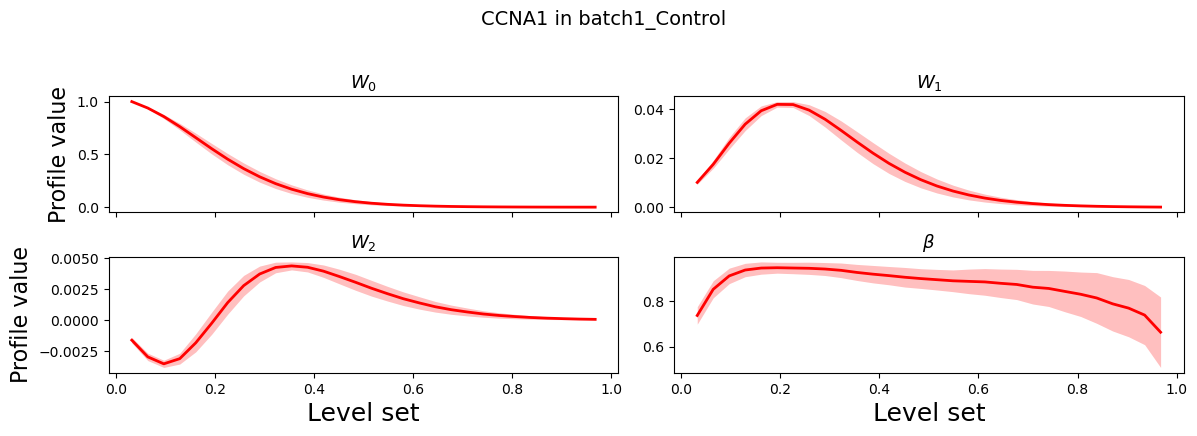

In [20]:
fig, axes = minkiPy.plot_minkowski_profile(
    data,
    dataset="batch1_Control",
    gene="CCNA1",
    use_scaled=False,
    n_sigma=1.0,
    figsize=(12.0, 4.4),
    show=True,
    savepath="examples/FSHD_dataset/fig1.pdf",
)

## Random Monte Carlo diagnostics

This cell shows a random grid of **Monte Carlo resampling distributions** for selected genes, statistics, and level sets.  
For each panel, the empirical distribution is compared with a **moment-matched Gaussian** as a simple diagnostic of the Gaussian approximation.

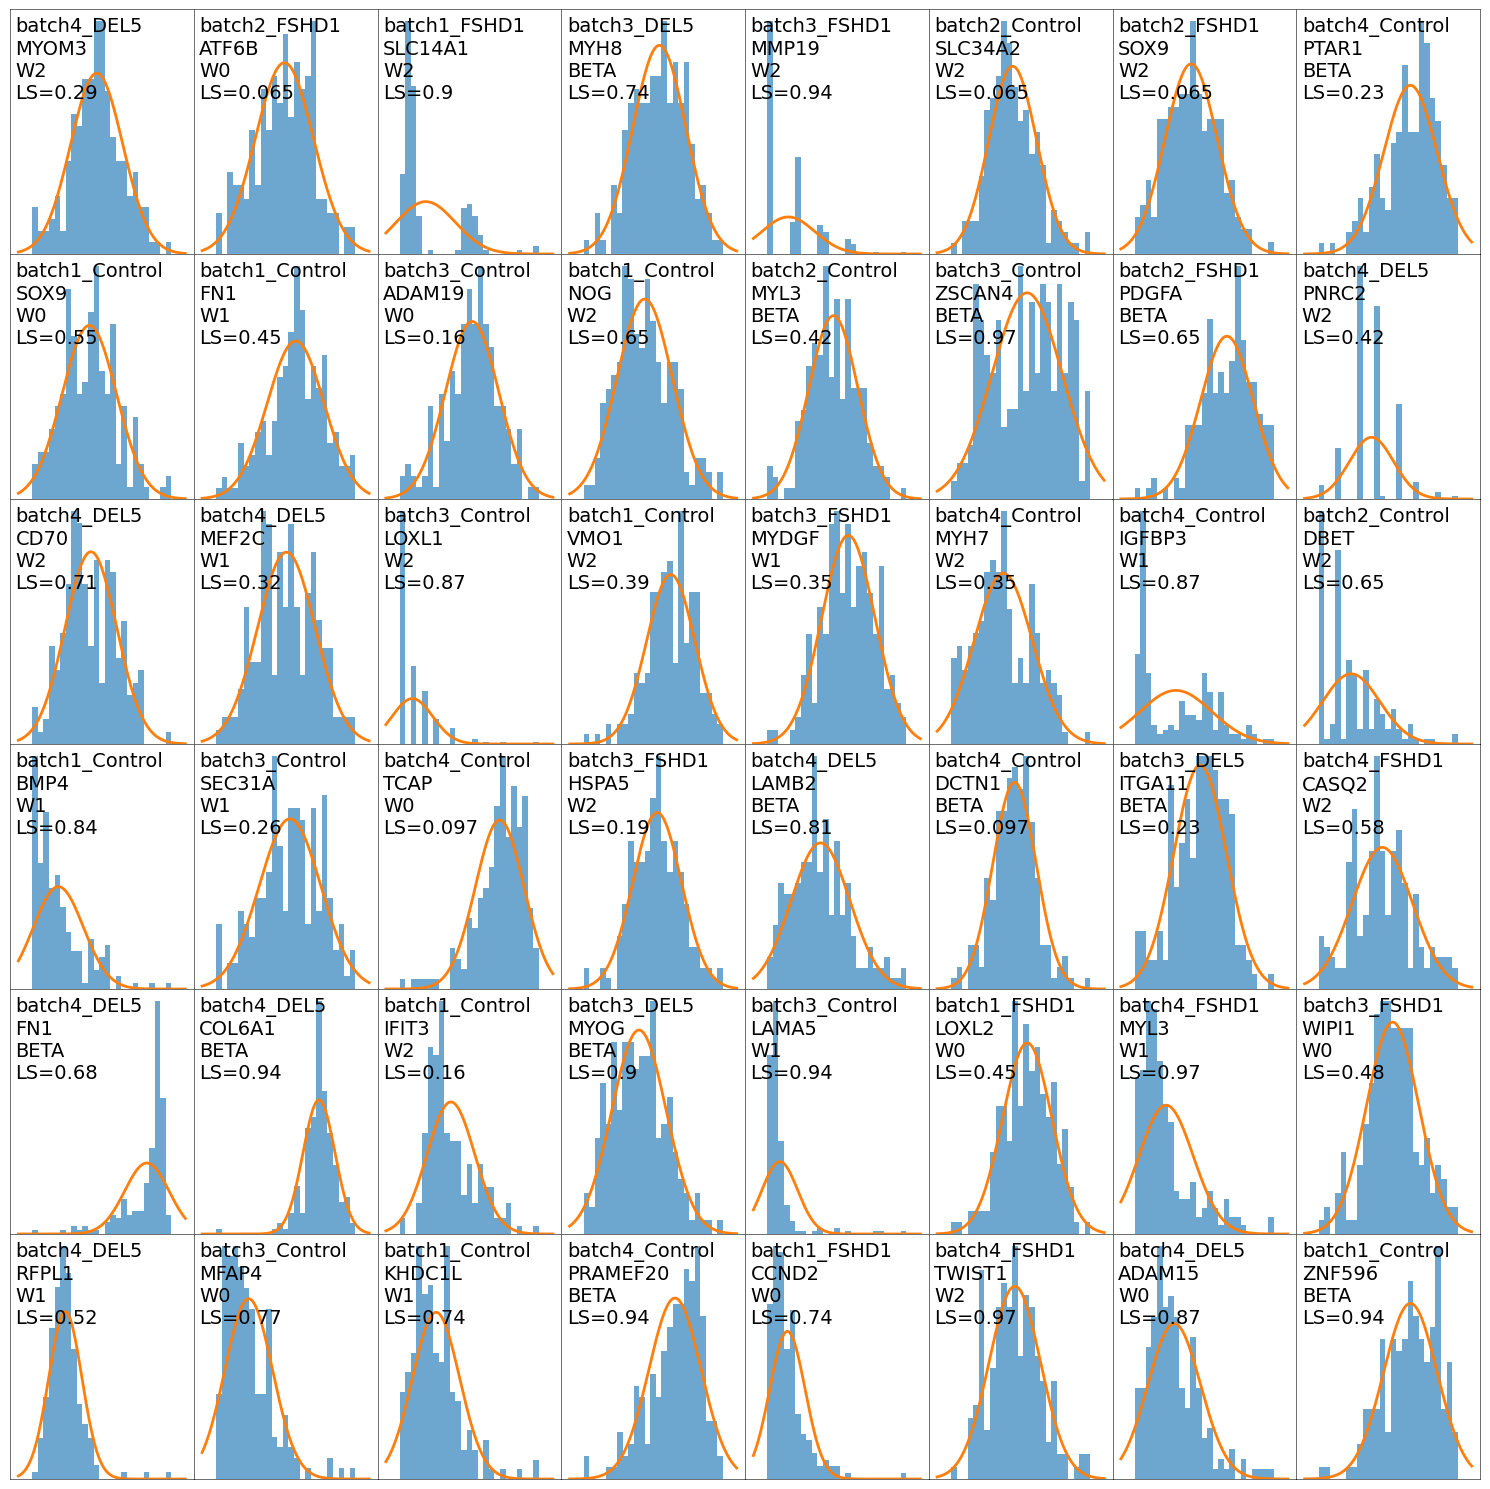

[saved] /mnt/DATA_11TB/projects/Spatial_Transcriptomics/MERFISH_FSHD_Public_Data/figures/mc_gauss_random_grid_seed0.pdf | skipped panels: 0/48


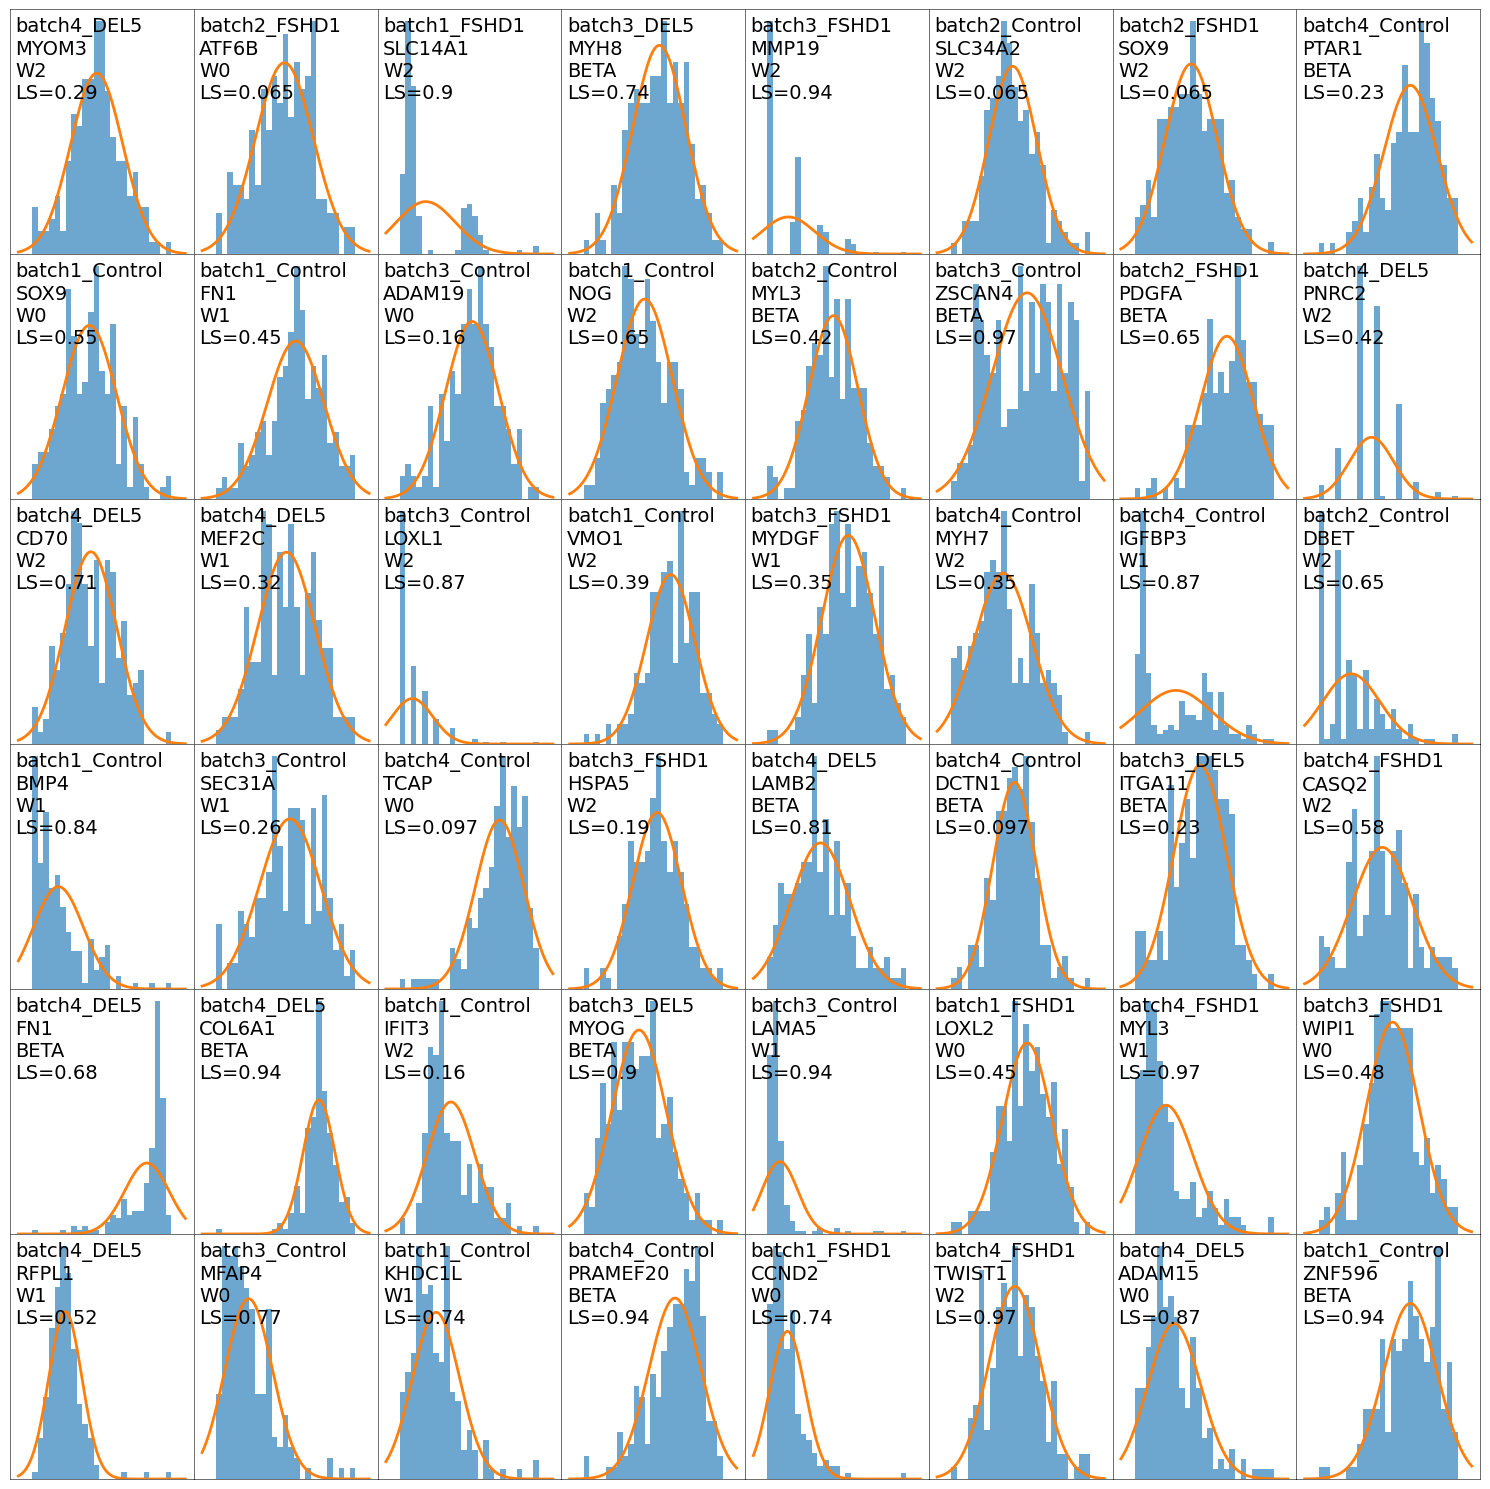

In [21]:
minkiPy.plot_random_mc_gaussian_overlay_grid(
    data,
    n_rows=6,
    n_cols=8,
    use_scaled=True,
    bins=25,
    seed=0,
    figsize=(15, 15),
    label_fontsize=14,
    save_pdf="examples/FSHD_dataset/fig2.pdf",
)

## Condition-level averaged datasets

This cell creates **condition-level averaged datasets** for **FSHD1**, **Control**, and **DEL5**.  
The averaged profiles are added to the main `data` object for downstream comparisons alongside the original samples.

In [22]:
groups_to_average = {
    "FSHD1_avg":  ['batch1_FSHD1','batch3_FSHD1','batch4_FSHD1'],
    "Control_avg":['batch1_Control','batch2_Control','batch3_Control','batch4_Control'],
    "DEL5_avg":   ['batch3_DEL5','batch4_DEL5'],
}

data = minkiPy.add_averaged_condition_datasets(
    data,
    groups=groups_to_average,
    ordered_conditions=ordered_conditions,
    verbose=True
)

[avg] Covariance matrices detected; averaged covariances will be propagated when possible.
[avg] Starting condition-level averaging from 10 datasets, 140 genes, 4 statistics and 30 level sets.
[avg] Appended 'FSHD1_avg' from 3 datasets (batch1_FSHD1, batch3_FSHD1, batch4_FSHD1); finite covariances for 140/140 genes.
[avg] Appended 'Control_avg' from 4 datasets (batch1_Control, batch2_Control, batch3_Control, batch4_Control); finite covariances for 140/140 genes.
[avg] Appended 'DEL5_avg' from 2 datasets (batch3_DEL5, batch4_DEL5); finite covariances for 140/140 genes.
[avg] Finished condition-level averaging: 3 appended, 0 overwritten, 0 skipped.


## Sample-to-sample distances

This cell computes **pairwise sample distances** across all datasets.  
Here we use the **full covariance-aware Wasserstein distance**, which compares samples from their gene-level Minkowski representations.

In [23]:
data = minkiPy.compute_sample_distances(
    data,
    diag_only=False, #True for faster computation (less precise)
    dataset_pairs="ALL",
    verbose=True,
)

[distance] Computing averaged sample distances for 78 dataset pairs (datasets=13, genes=140, feature_dim=120, mode=full-covariance Wasserstein, ridge=1e-06, transcript_weighting=on).


sample-distance(dataset pairs):   0%|          | 0/78 [00:00<?, ?it/s]

[distance] Completed 78 dataset pairs (mode=full-covariance Wasserstein, pairs_with_values=75, all_nan=3, finite_averages=75, nan_averages=3).
[distance] Per-gene distances cached in 'sample_distance_per_gene' with shape (13, 13, 140).


## Sample-level visualisation

This cell visualises **relationships between samples** using the computed distance matrix and low-dimensional embeddings.  
It shows sample-level **MDS**, **PCA**, **UMAP**, and a PCA based on **normalised gene densities**.

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


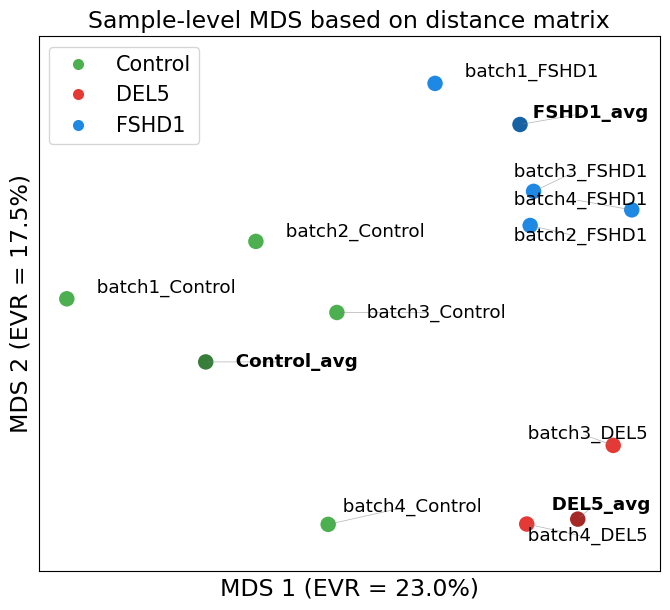

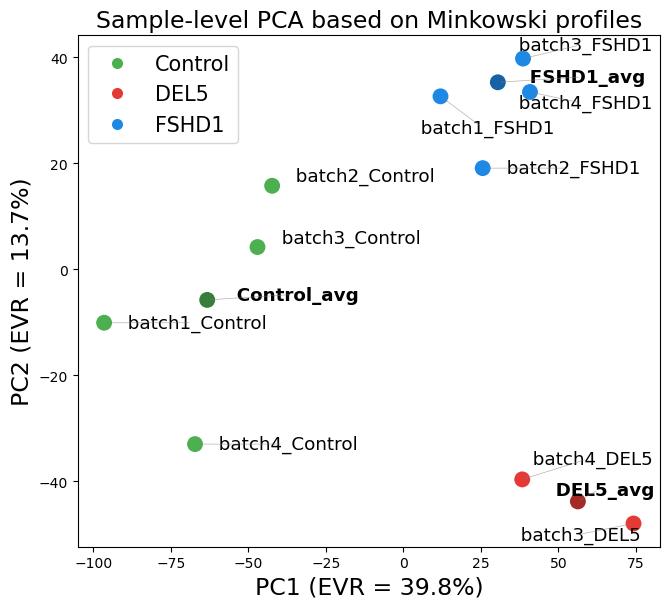

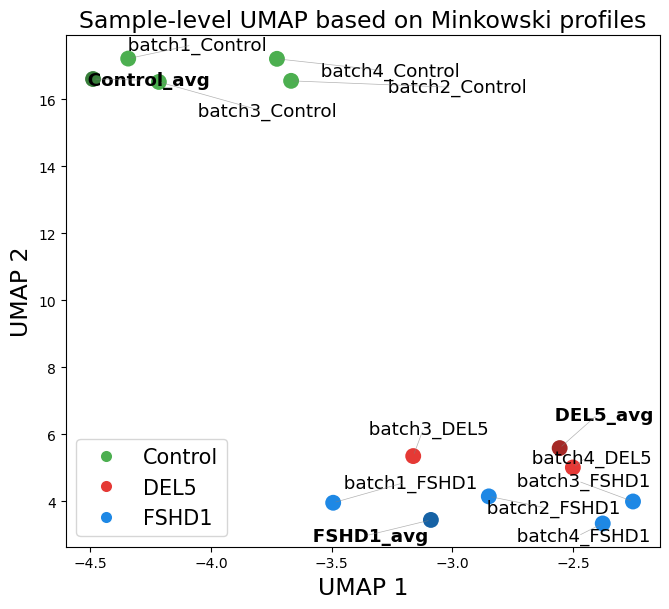

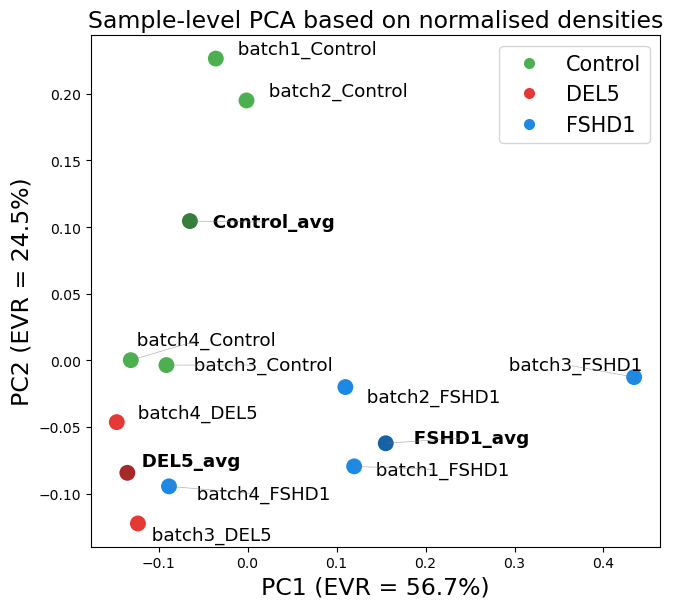

In [24]:
group_colors = {
    "Control": "#4CAF50",
    "FSHD1":   "#1E88E5",
    "DEL5":    "#E53935",
    "OTHER":   "#9E9E9E",
}

out = minkiPy.plot_dataset_graphs_from_data(
    data,
    ordered_conditions=ordered_conditions,
    groups=groups,
    group_colors=group_colors,
    avg_suffix="_avg",
    avg_darken_factor=0.72,
    show_others=False,
    others_group_name="OTHER",
    label_fontsize=13.2,
    edge_label_fontsize=7.0,
    legend_loc=None,
    legend_loc_w2="best",
    legend_loc_pca="best",
    legend_loc_umap="best",
    legend_loc_pca_density="best",
    marker_size=160.0,
    random_seed=0,
    umap_n_neighbors=5,
    umap_min_dist=0.05,
    umap_repulsion_strength=1.2,
    umap_parallel=True,
    include_density_pca=True,
    density_field="normalized_density",
    out_pdf_w2="examples/FSHD_dataset/fig3.pdf",
    out_pdf_pca="examples/FSHD_dataset/fig4.pdf",
    out_pdf_umap="examples/FSHD_dataset/fig5.pdf",
    out_pdf_pca_density="examples/FSHD_dataset/fig6.pdf",
)

## Gene-pair distances across averaged conditions

This cell computes **gene-pair distances** between the averaged **DEL5**, **FSHD1**, and **Control** datasets.  
We first compute the **full covariance-aware Wasserstein distance**, then a **diagonal approximation** together with the corresponding **Euclidean distances** for comparison.

In [25]:
data = minkiPy.compute_gene_distances(
    data,
    datasets=["DEL5_avg","FSHD1_avg","Control_avg"],
    diag_only=False,
)

data = minkiPy.compute_gene_distances(
    data,
    datasets=["DEL5_avg","FSHD1_avg","Control_avg"],
    diag_only=True,
    run_name="W2_diag",
    add_euclidean = True
)

[gene-distance] Computing full-covariance Wasserstein distances for 3 datasets, 140 genes, feature_dim=120, ridge=1e-08.


gene distances:   0%|          | 0/6 [00:00<?, ?it/s]

[gene-distance] Full-covariance Wasserstein path filled 176400/176400 entries.
[gene-distance] Stored run 'datasets:DEL5_avg,FSHD1_avg,Control_avg' (distance_kind=wasserstein) for datasets: DEL5_avg, FSHD1_avg, Control_avg.
[gene-distance] Within-dataset blocks: DEL5_avg|DEL5_avg, FSHD1_avg|FSHD1_avg, Control_avg|Control_avg
[gene-distance] Between-dataset blocks: DEL5_avg|FSHD1_avg, DEL5_avg|Control_avg, FSHD1_avg|Control_avg
[gene-distance] Computing diag-only Wasserstein distances for 3 datasets, 140 genes, feature_dim=120, ridge=1e-08.
[gene-distance] Euclidean gene-pair distances will also be stored.


gene distances:   0%|          | 0/6 [00:00<?, ?it/s]

[gene-distance] Diagonal Wasserstein path filled 176400/176400 entries.
[gene-distance] Stored run 'W2_diag' (distance_kind=wasserstein) for datasets: DEL5_avg, FSHD1_avg, Control_avg.
[gene-distance] Within-dataset blocks: DEL5_avg|DEL5_avg, FSHD1_avg|FSHD1_avg, Control_avg|Control_avg
[gene-distance] Between-dataset blocks: DEL5_avg|FSHD1_avg, DEL5_avg|Control_avg, FSHD1_avg|Control_avg
[gene-distance] Euclidean block tensors were stored alongside the main distance tensor.


## Comparing distance definitions

This cell compares the distributions of **full Wasserstein**, **diagonal Wasserstein**, and **Euclidean** gene-pair distances.  
It provides a simple diagnostic of how much information is lost when using the diagonal approximation or ignoring covariance structure.

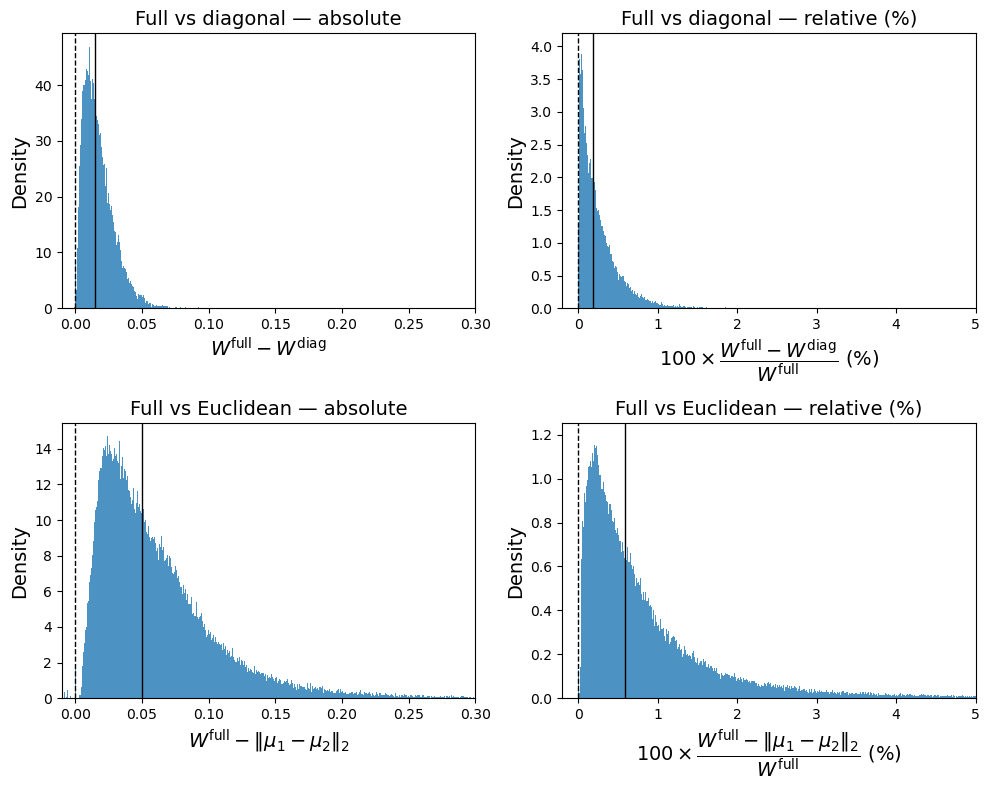

In [26]:
fig, axes = minkiPy.plot_w2_diag_vs_full_plus_euclid_distributions(
    data,
    run_full="datasets:DEL5_avg,FSHD1_avg,Control_avg",
    run_diag="W2_diag",
    bins=1000,
    density=True,
    max_rel_pct=10,
    xlim_abs=(-0.01, 0.3),
    xlim_rel=(-0.2, 5),
    save_path="examples/FSHD_dataset/fig7.pdf",
)

## Gene-level graph and low-dimensional views

This cell uses the **gene-pair distance matrix** to build a graph and to compute the **MDS** representation.  
In parallel, it uses the **Minkowski profiles** themselves to compute the **PCA** and **UMAP** views, while highlighting the selected **genes of interest** and reporting the inferred gene clusters.

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== Cluster summary (nodes/genes/retention/dataset composition/mean densities) ===
 Cluster  n_nodes  n_genes  Retention [%]  GOI nodes [%]  GOI genes covered [%]  Control_avg [%] Control_avg mean density  FSHD1_avg [%] FSHD1_avg mean density  DEL5_avg [%] DEL5_avg mean density
       0      186       89      40.449438       3.763441              25.000000        41.935484                1.096e-02      25.806452              1.140e-02     32.258065             1.424e-02
       1      181      101      23.762376      13.259669              91.666667        34.254144                8.768e-03      33.149171              7.495e-03     32.596685             1.145e-02
       2       53       33       0.000000      77.358491              91.666667         0.000000                1.339e-03      60.377358              6.210e-03     39.622642             3.020e-03


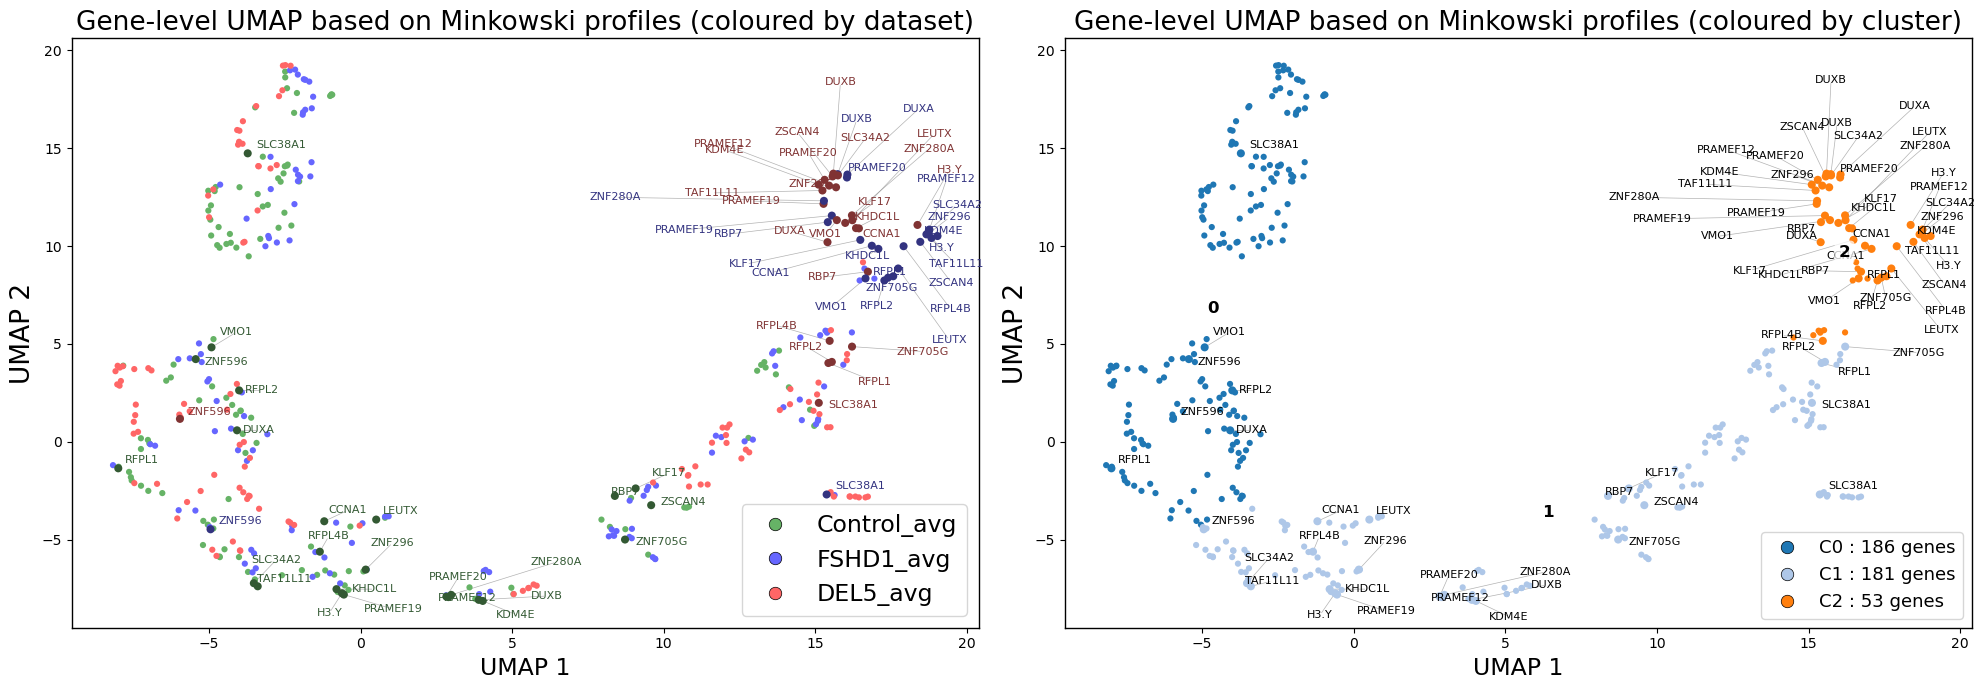

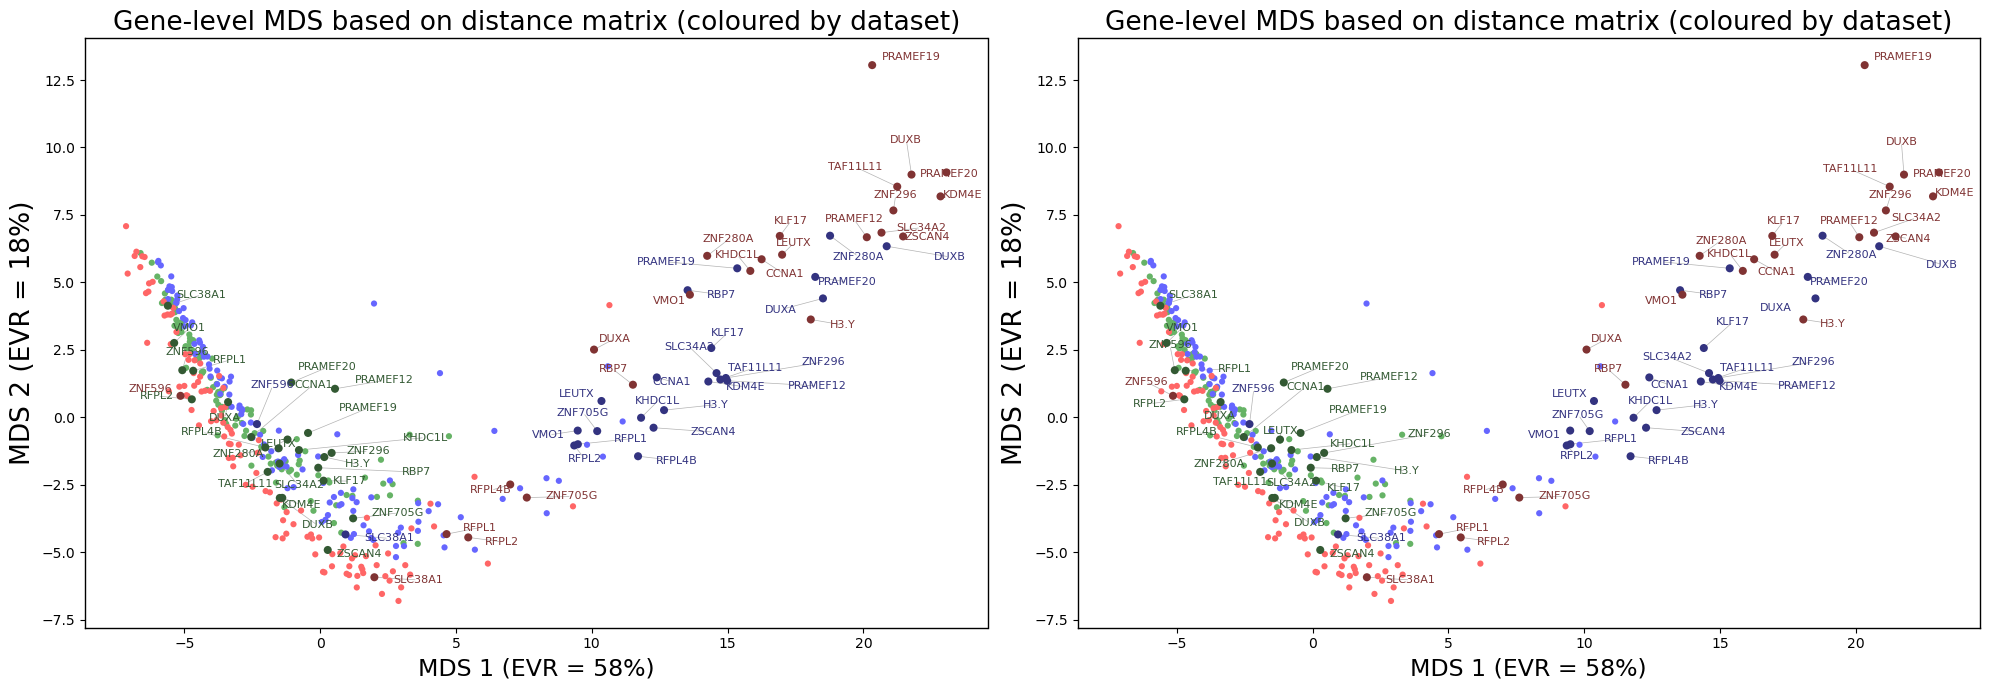

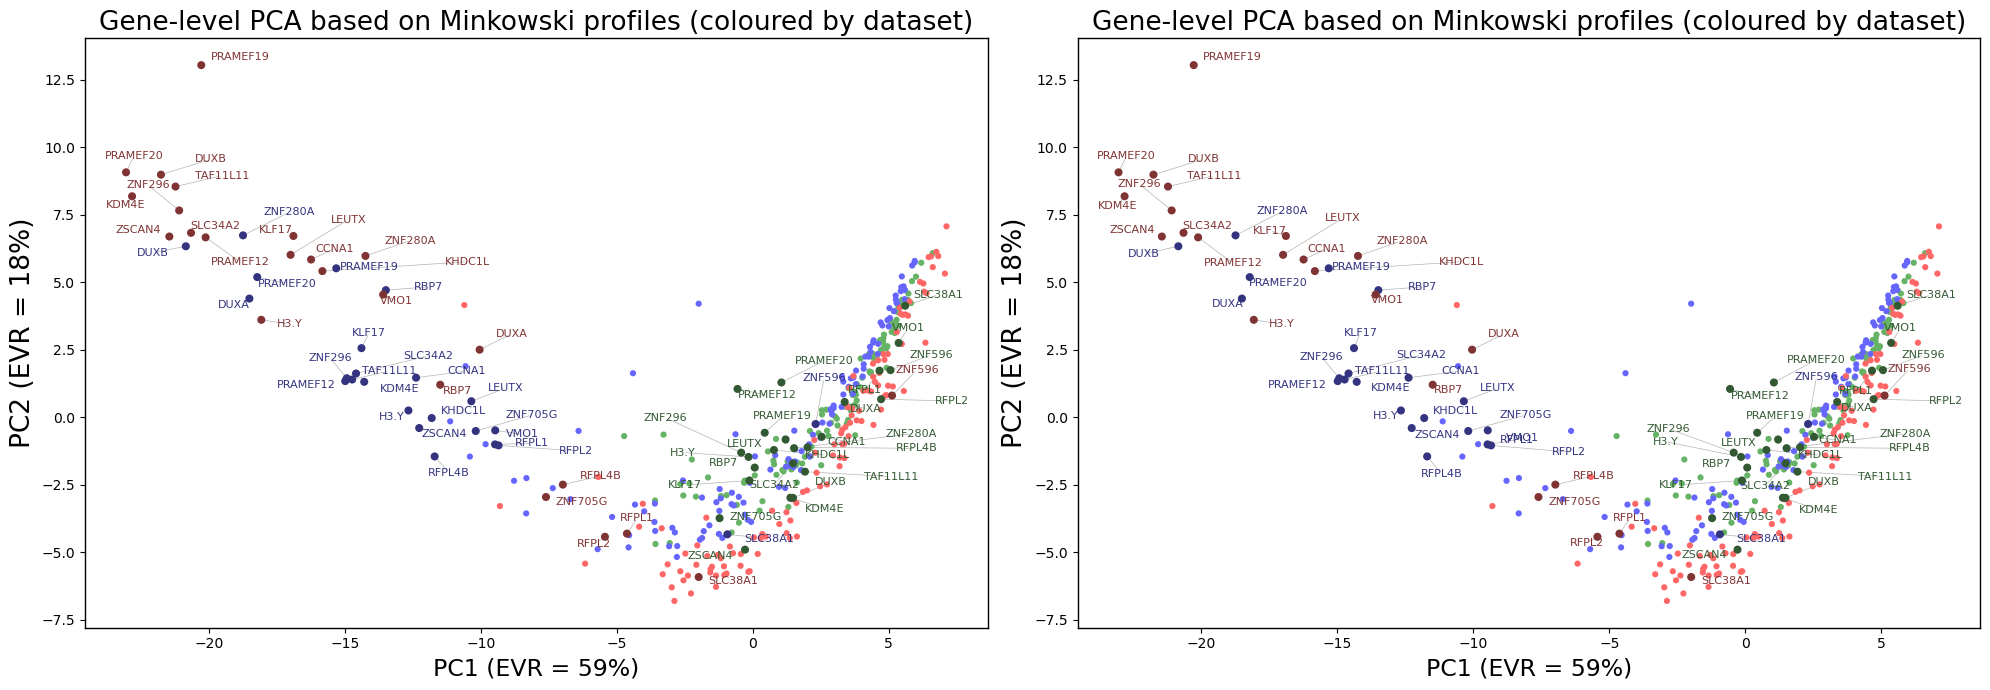

In [27]:
ds_palette_fshd = {
    "Control_avg": "green",
    "FSHD1_avg": "blue",
    "DEL5_avg": "red",
}

res_fshd = minkiPy.plot_gene_graphs_from_data(
    data,
    datasets=["Control_avg", "FSHD1_avg", "DEL5_avg"],
    graph_mode="knn",
    k=25,
    add_mst=True,
    layout="umap",
    prefer_partition="leiden",
    resolution=0.05,
    edge_mode="mst",
    edge_alpha=0.0,
    node_size=20.0,
    node_alpha=1.0,
    umap_n_neighbors=5,
    umap_min_dist=0.01,
    umap_spread=2.5,
    genes_to_label=GOI,
    goi_text_size=8,
    goi_marker_scale=1.3,
    goi_darken=0.50,
    dataset_palette=ds_palette_fshd,
    dataset_lighten=0.40,
    legend_loc_datasets="best",
    show_cluster_legend=True,
    legend_loc_clusters="best",
    cluster_legend_fontsize=13,
    make_pca_figure=True,
    out_umap_pdf="examples/FSHD_dataset/fig8.pdf",
    out_mds_pdf="examples/FSHD_dataset/fig9.pdf",
    out_pca_pdf="examples/FSHD_dataset/fig10.pdf",
    random_seed=0,
    print_cluster_info=True,
    out_cluster_membership_csv="examples/FSHD_dataset/table1.csv",
)

## PCA within each condition

This cell shows a **per-sample PCA** of gene-level Minkowski profiles, organised by condition.  
Each panel is computed independently, which makes it possible to inspect the internal gene structure of each sample and averaged condition.

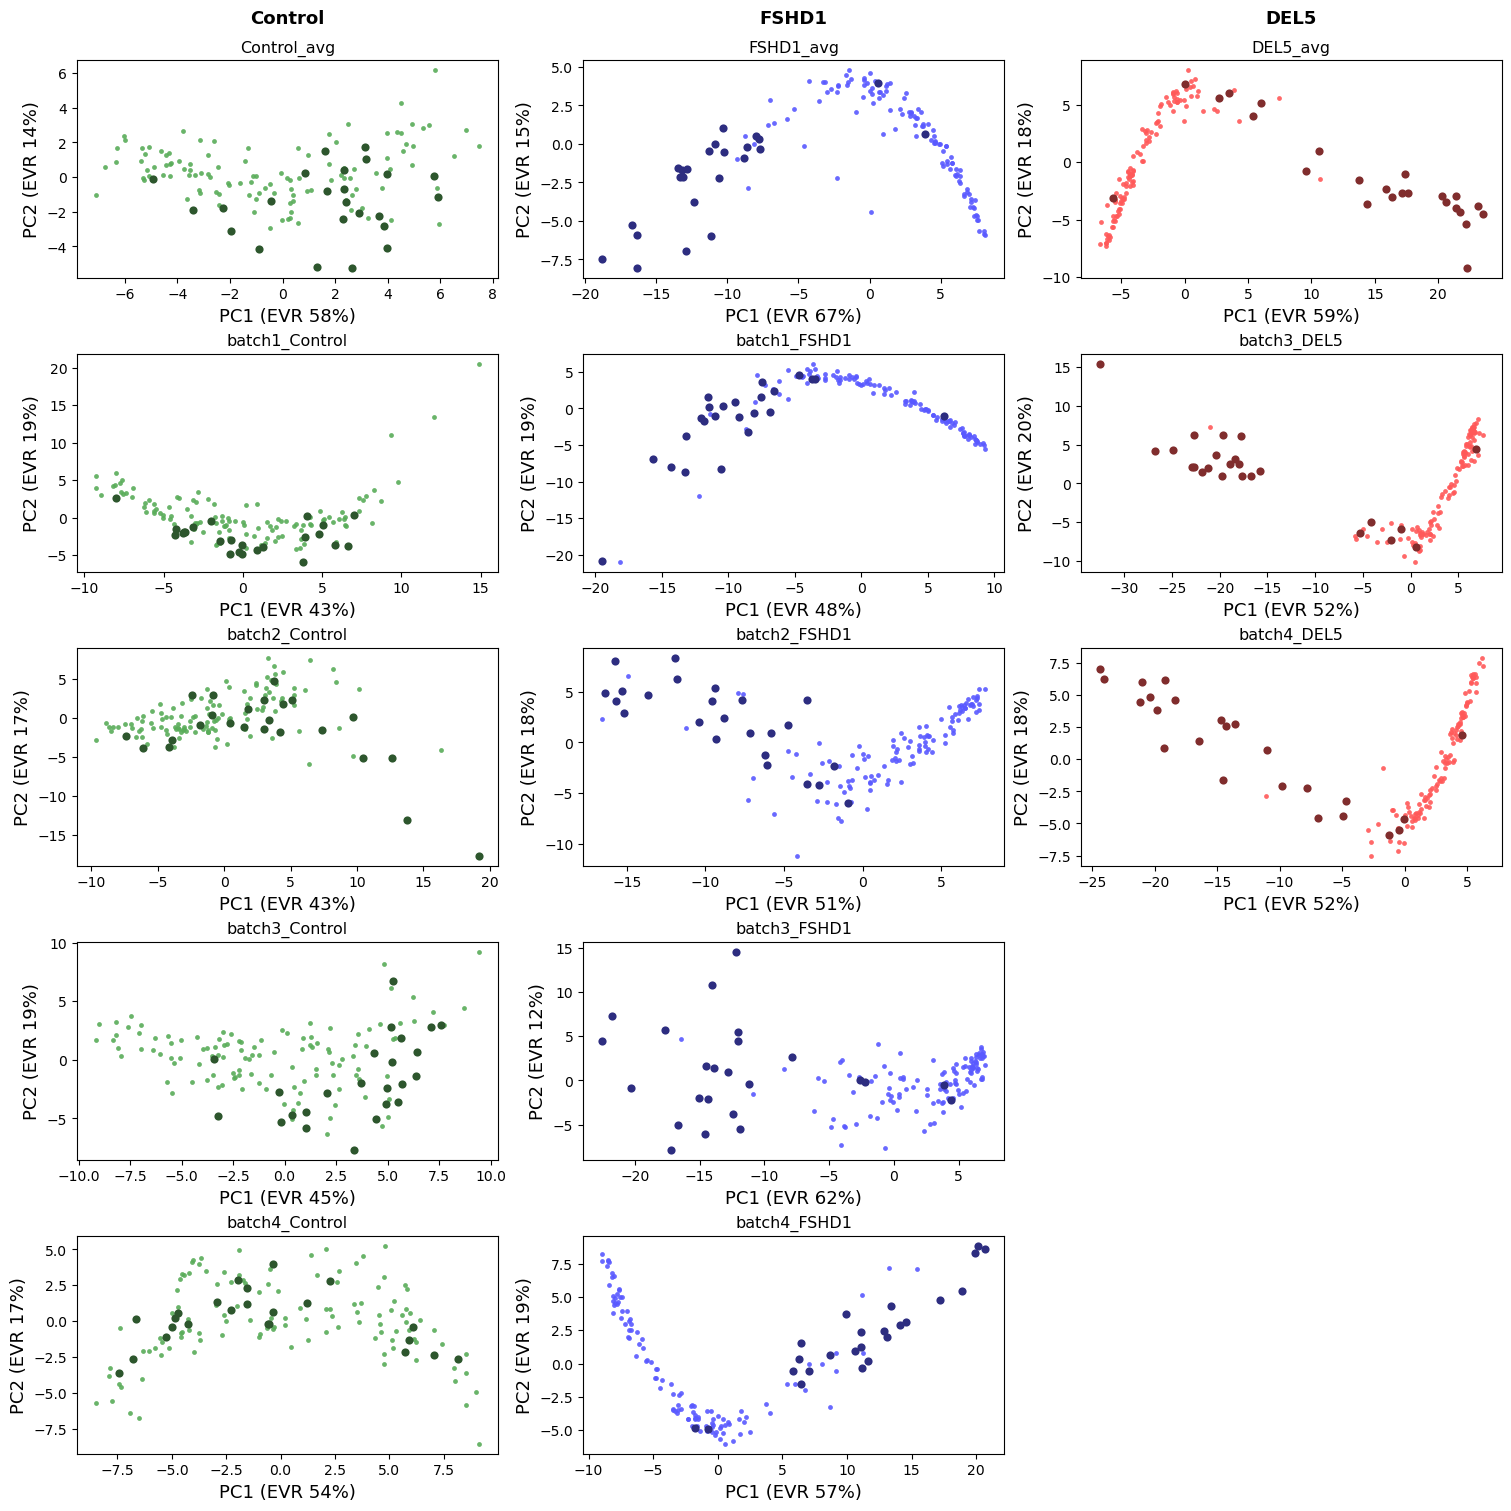

In [28]:
group_palette = {"Control": "green", "FSHD1": "blue", "DEL5": "red"}

fig, axes, out = minkiPy.plot_pca_grid_by_condition(
    data,
    group_order=("Control", "FSHD1", "DEL5"),
    group_palette=group_palette,
    use_scaled=True,
    genes_to_label=GOI,
    label_goi=False,
    figsize=(15, 15), 
    save_pdf="examples/FSHD_dataset/fig11.pdf",
)

## Top genes with the largest spatial change

These cells rank genes by their **same-gene distance** between pairs of averaged conditions.  
For each comparison, the plots highlight the genes with the largest changes in spatial organisation and relate them to the corresponding changes in normalised gene density.

[plot_top_changing_genes] W2 percentile lines: p50=5.43262, p90=14.9821, p95=17.3329


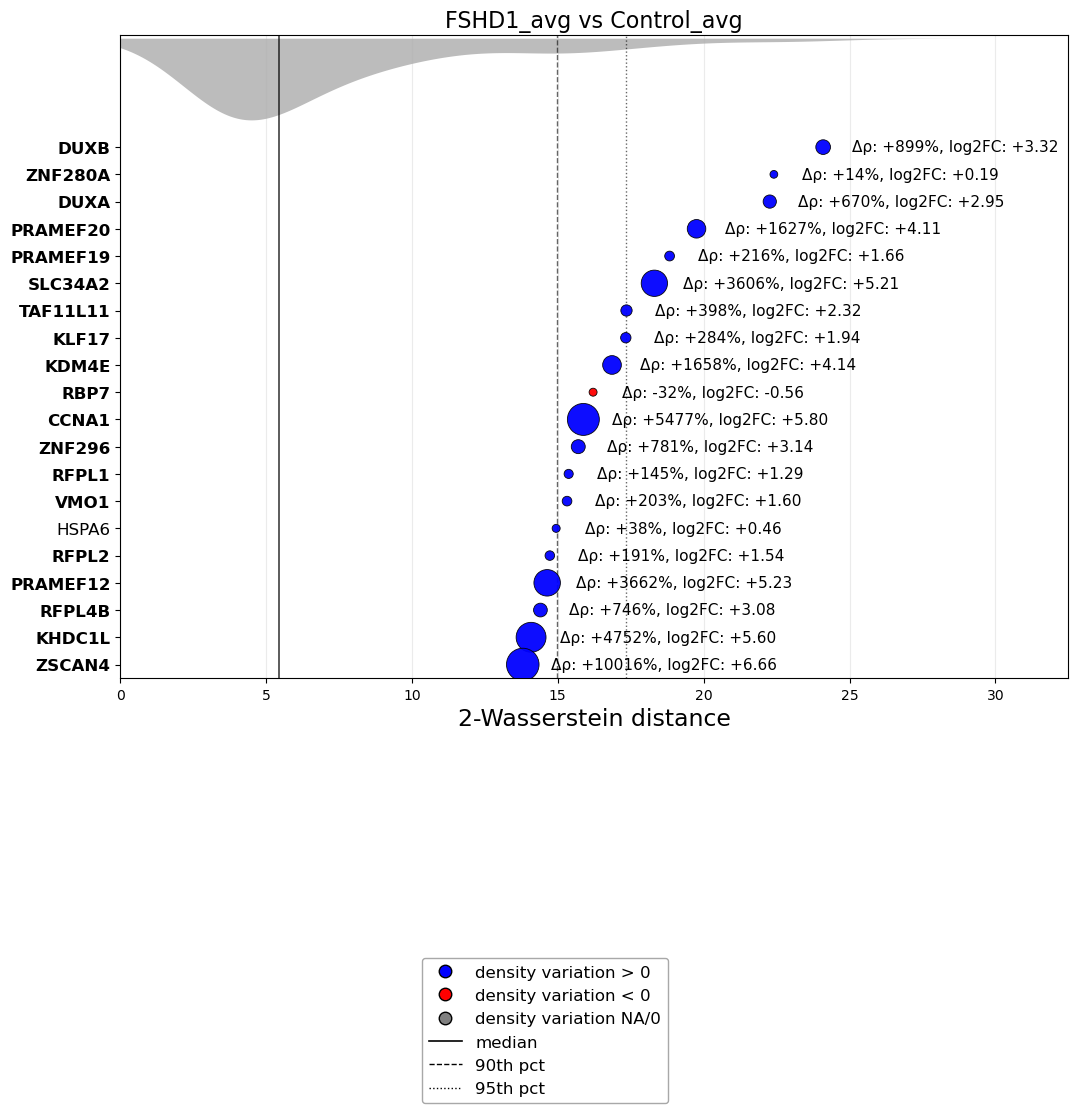

[plot_top_changing_genes] W2 percentile lines: p50=6.16312, p90=19.3563, p95=22.7136


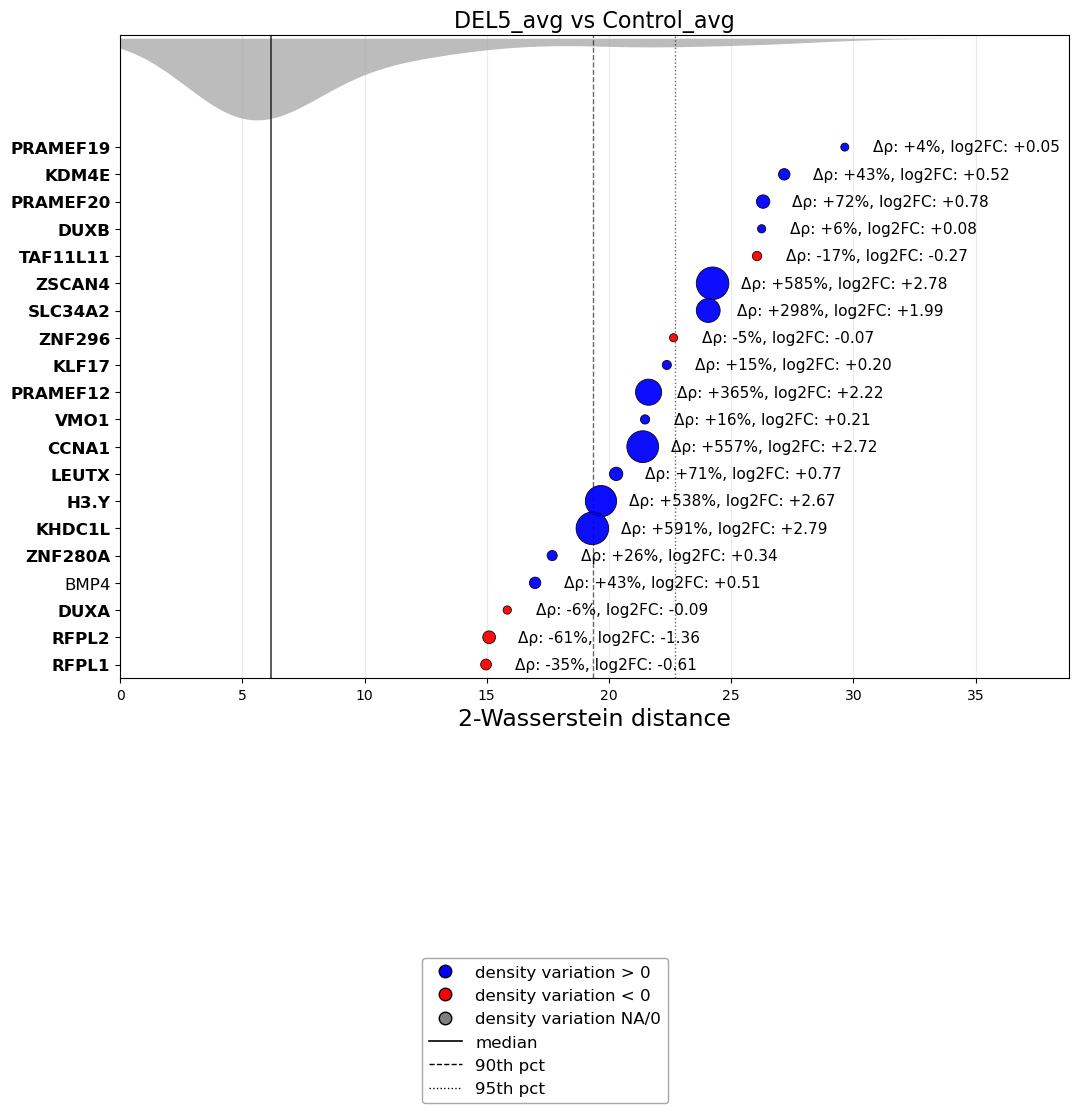

[plot_top_changing_genes] W2 percentile lines: p50=6.06846, p90=10.5743, p95=11.6829


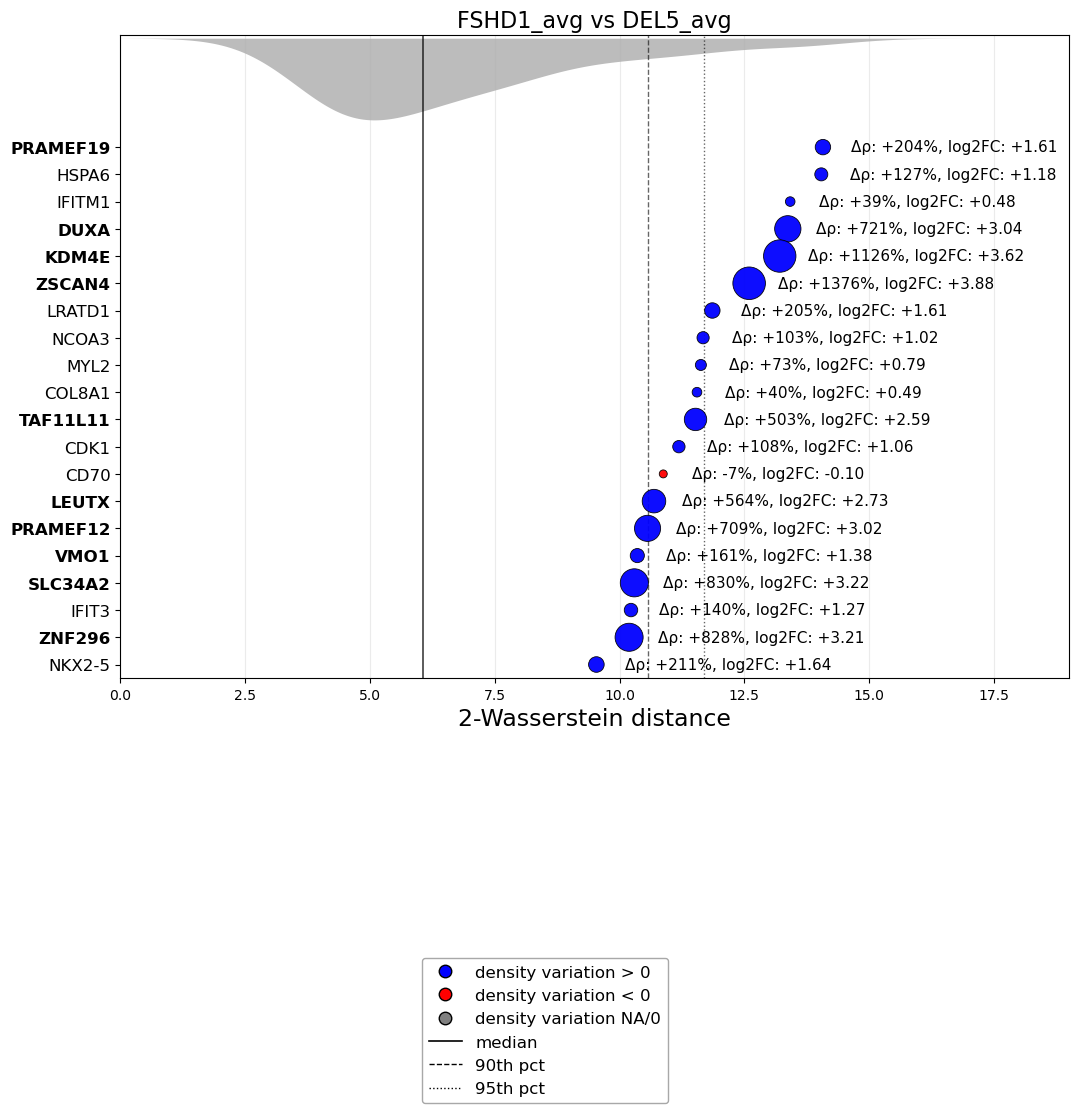

In [11]:
out1 = minkiPy.plot_top_changing_genes(
    data,
    dataset_A="FSHD1_avg",
    dataset_B="Control_avg",
    top_k=20,
    save_csv="examples/FSHD_dataset/table2.csv",
    save_pdf="examples/FSHD_dataset/fig12.pdf",
    xlim_max=32.5,
)

out2 = minkiPy.plot_top_changing_genes(
    data,
    dataset_A="DEL5_avg",
    dataset_B="Control_avg",
    top_k=20,
    save_csv="examples/FSHD_dataset/table3.csv",
    save_pdf="examples/FSHD_dataset/fig13.pdf",
    xlim_max=38.8,
)

out3 = minkiPy.plot_top_changing_genes(
    data,
    dataset_A="FSHD1_avg",
    dataset_B="DEL5_avg",
    top_k=20,
    save_csv="examples/FSHD_dataset/table4.csv",
    save_pdf="examples/FSHD_dataset/fig14.pdf",
    xlim_max=19,
)

## Spatial change versus abundance change

These cells compare the **same-gene Wasserstein distance** with the corresponding **absolute log2 fold-change** in normalised density.  
This provides a simple way to assess how strongly changes in spatial organisation are associated with changes in gene abundance across conditions.

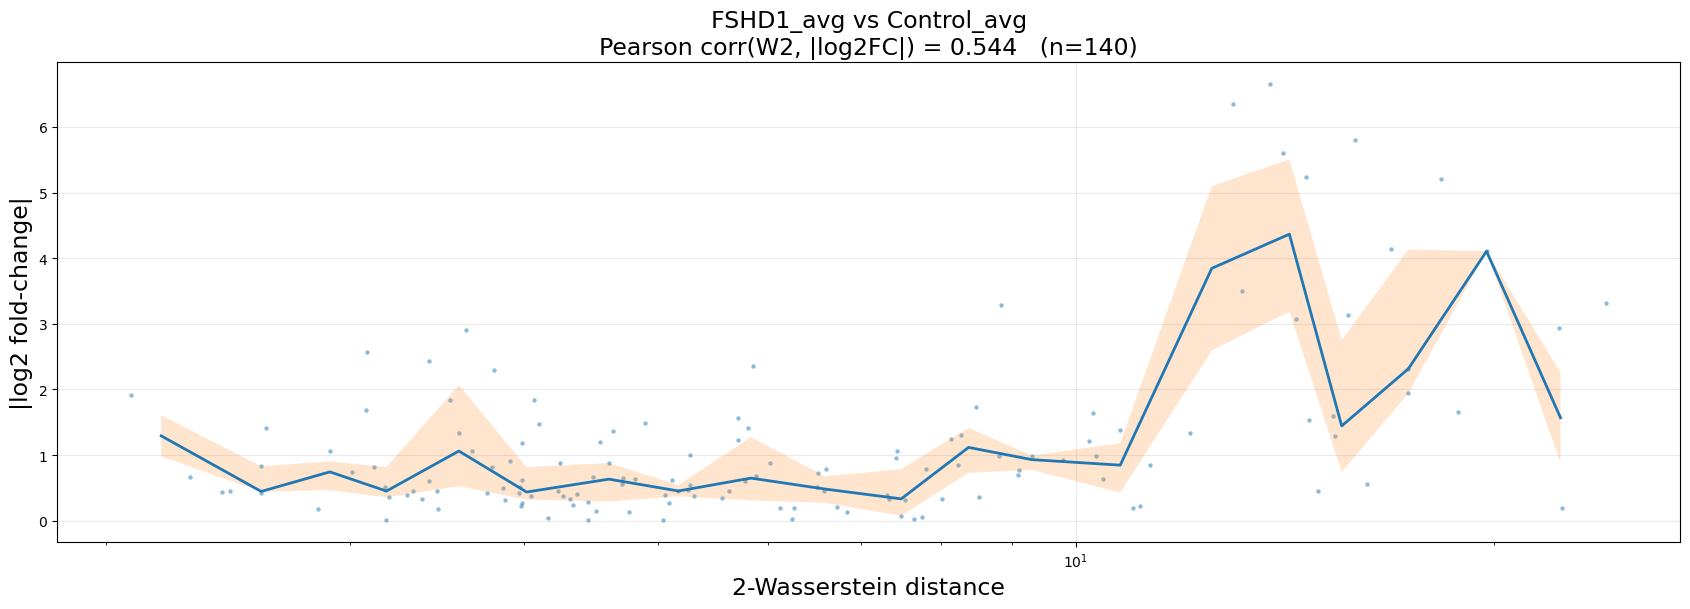

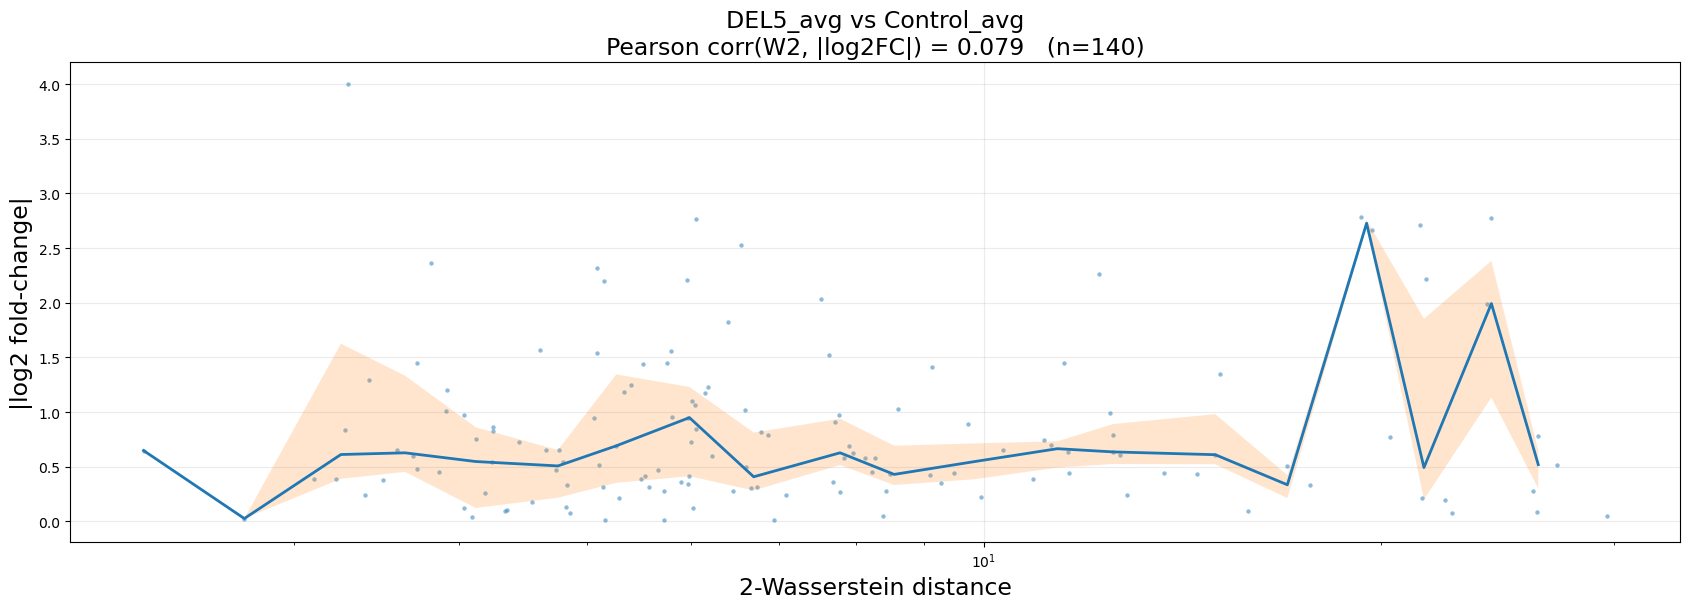

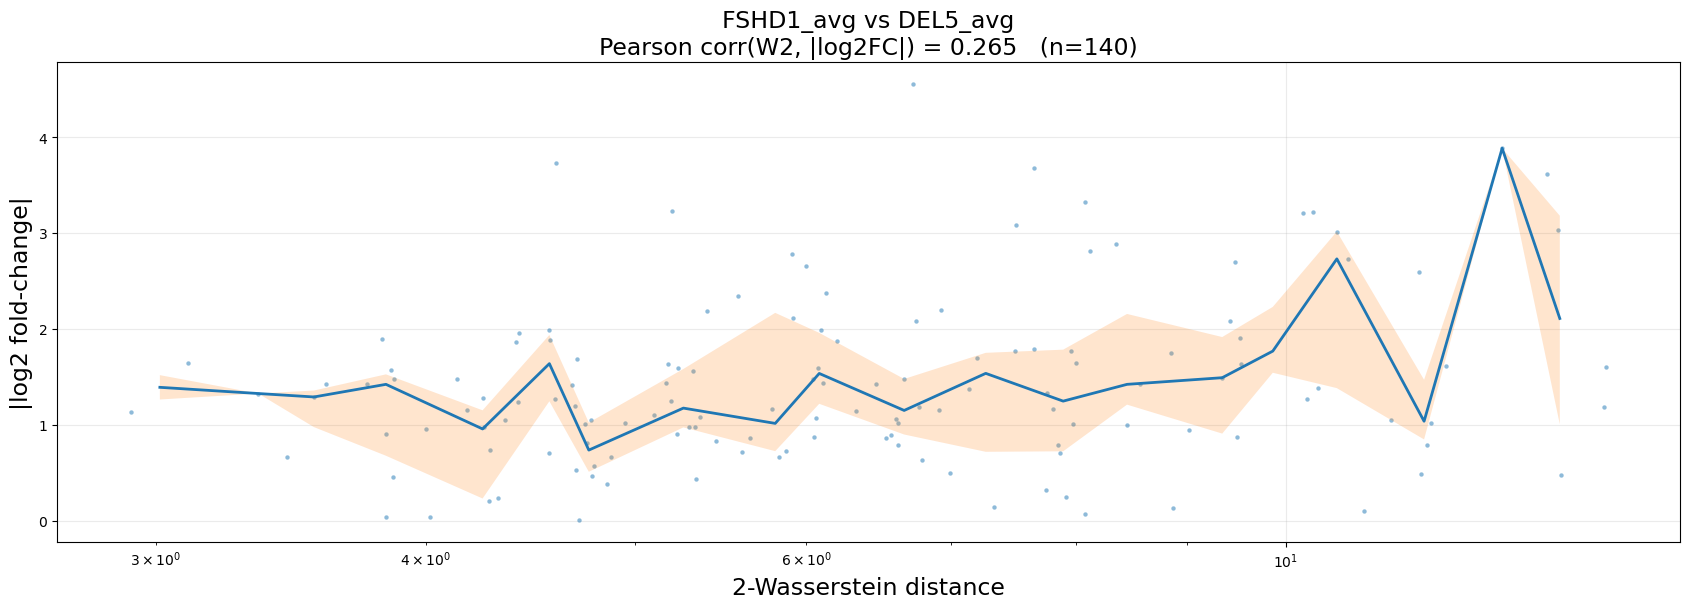

In [12]:
stats = minkiPy.plot_w2_abslog2fc_with_trend(
    data,
    dataset_A="FSHD1_avg",
    dataset_B="Control_avg",
    density_field="normalized_density",
    logfc_eps=1e-6,
    xscale="log",
    binning="log",
    nbins=20,
    show_iqr=True,
    show_regression=False,
    save_pdf="examples/FSHD_dataset/fig15.pdf",
)

stats = minkiPy.plot_w2_abslog2fc_with_trend(
    data,
    dataset_A="DEL5_avg",
    dataset_B="Control_avg",
    density_field="normalized_density",
    logfc_eps=1e-6,
    xscale="log",
    binning="log",
    nbins=20,
    show_iqr=True,
    show_regression=False,
    save_pdf="examples/FSHD_dataset/fig16.pdf",
)

stats = minkiPy.plot_w2_abslog2fc_with_trend(
    data,
    dataset_A="FSHD1_avg",
    dataset_B="DEL5_avg",
    density_field="normalized_density",
    logfc_eps=1e-6,
    xscale="log",
    binning="log",
    nbins=20,
    show_iqr=True,
    show_regression=False,
    save_pdf="examples/FSHD_dataset/fig17.pdf",
)
